## Tweet Emotion Recognition: Natural Language Processing with TensorFlow

---

Dataset: [Tweet Emotion Dataset](https://github.com/dair-ai/emotion_dataset)

This is a starter notebook for the guided project [Tweet Emotion Recognition with TensorFlow](https://www.coursera.org/projects/tweet-emotion-tensorflow)

A complete version of this notebook is available in the course resources

---

## Task 1: Introduction

## Task 2: Setup and Imports

1. Installing Hugging Face's nlp package
2. Importing libraries

In [14]:
!pip install -U datasets

In [2]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nlp
import random


def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()


print('Using TensorFlow version', tf.__version__)

Using TensorFlow version 2.19.0


## Task 3: Importing Data

1. Importing the Tweet Emotion dataset
2. Creating train, validation and test sets
3. Extracting tweets and labels from the examples

In [15]:
from datasets import load_dataset

emotions = load_dataset('emotion')

train_ds = emotions['train']
val_ds = emotions['validation']
test_ds = emotions['test']

def get_tweets(data):
    tweets = [x['text'] for x in data]
    return tweets

def get_labels(data):
    labels = [x['label'] for x in data]
    return labels

tweets = get_tweets(train_ds)
labels = get_labels(train_ds)

print(f"Train dataset size: {len(train_ds)}")
print(f"Validation dataset size: {len(val_ds)}")
print(f"Test dataset size: {len(test_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train dataset size: 16000
Validation dataset size: 2000
Test dataset size: 2000


## Task 4: Tokenizer

1. Tokenizing the tweets

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Max vocabulary size to consider
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
tokenizer.fit_on_texts(tweets)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("First 10 words in vocabulary:")
for i, word in enumerate(tokenizer.word_index.keys()):
    if i == 10:
        break
    print(f"{i+1}. {word}")

Vocabulary size: 15213
First 10 words in vocabulary:
1. <unk>
2. i
3. feel
4. and
5. to
6. the
7. a
8. feeling
9. that
10. of


## Task 5: Padding and Truncating Sequences

1. Checking length of the tweets
2. Creating padded sequences

Max tweet length: 66
Min tweet length: 2
Average tweet length: 19.17


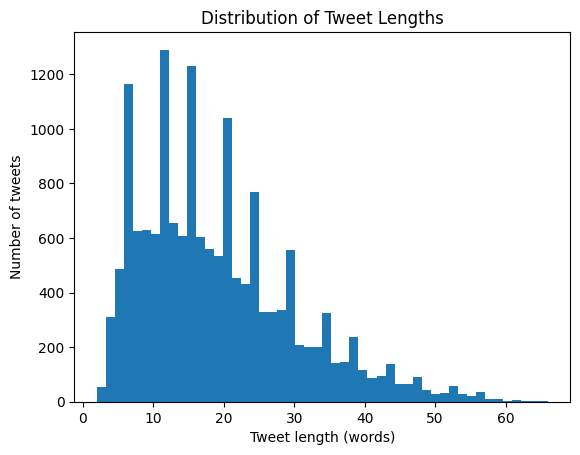


Shape of training sequences: (16000, 100)
Shape of validation sequences: (2000, 100)
Shape of test sequences: (2000, 100)

Example of a padded sequence (first tweet):
[  2 139   3 679   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]


In [17]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Calculate tweet lengths
tweets_lengths = [len(tweet.split(' ')) for tweet in tweets]
print(f"Max tweet length: {np.max(tweets_lengths)}")
print(f"Min tweet length: {np.min(tweets_lengths)}")
print(f"Average tweet length: {np.mean(tweets_lengths):.2f}")

# Plot histogram of tweet lengths
plt.hist(tweets_lengths, bins=50)
plt.xlabel('Tweet length (words)')
plt.ylabel('Number of tweets')
plt.title('Distribution of Tweet Lengths')
plt.show()

# Define MAX_LENGTH based on observation (e.g., typically around 50-100 for tweets)
# Let's choose 100 to cover most tweets
MAX_LENGTH = 100

def get_sequences(tokenizer, texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
    return padded_sequences

# Get sequences for train, validation, and test sets
train_tweets_sequences = get_sequences(tokenizer, get_tweets(train_ds))
val_tweets_sequences = get_sequences(tokenizer, get_tweets(val_ds))
test_tweets_sequences = get_sequences(tokenizer, get_tweets(test_ds))

print(f"\nShape of training sequences: {train_tweets_sequences.shape}")
print(f"Shape of validation sequences: {val_tweets_sequences.shape}")
print(f"Shape of test sequences: {test_tweets_sequences.shape}")

print("\nExample of a padded sequence (first tweet):")
print(train_tweets_sequences[0])

## Task 6: Preparing the Labels

1. Creating classes to index and index to classes dictionaries
2. Converting text labels to numeric labels

In [18]:
import numpy as np

# Get class names from the dataset features
class_names = train_ds.features['label'].names
num_classes = len(class_names)

# Create class to index and index to class dictionaries
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for i, name in enumerate(class_names)}

print(f"Number of classes: {num_classes}")
print(f"Class to index mapping: {class_to_index}")
print(f"Index to class mapping: {index_to_class}")

# Convert labels to numpy arrays (they are already numerical integers)
train_labels = np.array(get_labels(train_ds))
val_labels = np.array(get_labels(val_ds))
test_labels = np.array(get_labels(test_ds))

print(f"\nShape of training labels: {train_labels.shape}")
print(f"Shape of validation labels: {val_labels.shape}")
print(f"Shape of test labels: {test_labels.shape}")

print("\nExample of first 5 training labels:")
print(train_labels[:5])

Number of classes: 6
Class to index mapping: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
Index to class mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

Shape of training labels: (16000,)
Shape of validation labels: (2000,)
Shape of test labels: (2000,)

Example of first 5 training labels:
[0 0 3 2 3]


## Task 7: Creating the Model

1. Creating the model
2. Compiling the model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

EMBEDDING_DIM = 100

model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LENGTH),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 8: Training the Model

1. Preparing a validation set
2. Training the model

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.4635 - loss: 1.3969 - val_accuracy: 0.8245 - val_loss: 0.5218
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8850 - loss: 0.3557 - val_accuracy: 0.9080 - val_loss: 0.2751
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9480 - loss: 0.1458 - val_accuracy: 0.9090 - val_loss: 0.2590
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9704 - loss: 0.0865 - val_accuracy: 0.9175 - val_loss: 0.2520
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9792 - loss: 0.0636 - val_accuracy: 0.9130 - val_loss: 0.3074
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9832 - loss: 0.0503 - val_accuracy: 0.9195 - val_loss: 0.2574
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9860 - loss: 0.0381 - val_accuracy: 0.9180 - val_loss: 0.3048
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9883 - loss: 0.0317 - 

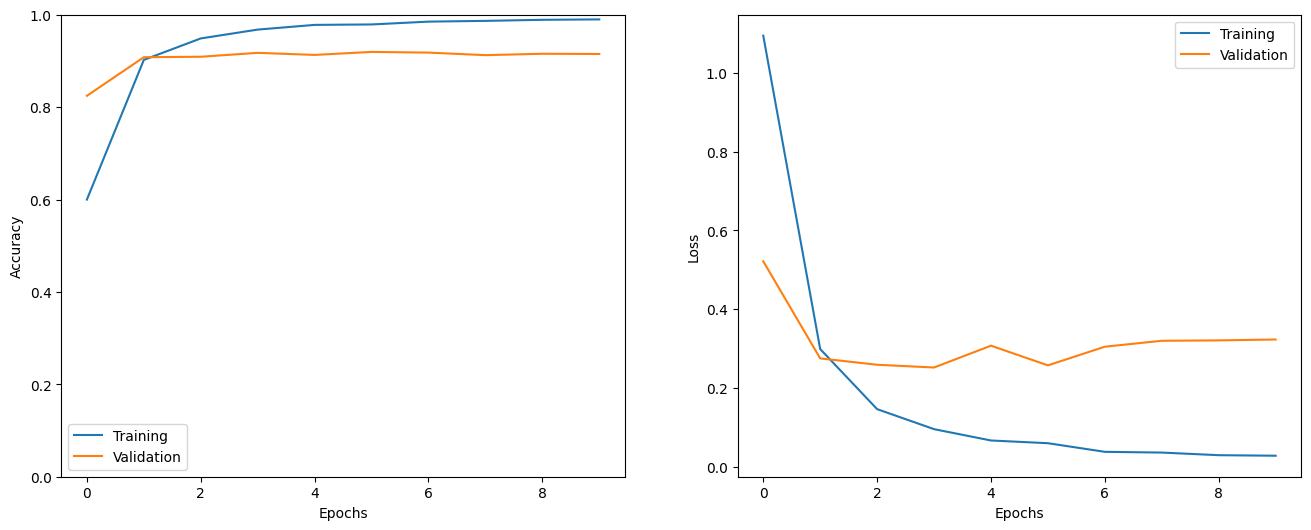

In [20]:
EPOCHS = 10
BATCH_SIZE = 32

history = model.fit(
    train_tweets_sequences,
    train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(val_tweets_sequences, val_labels)
)

show_history(history)

## Task 9: Evaluating the Model

1. Visualizing training history
2. Prepraring a test set
3. A look at individual predictions on the test set
4. A look at all predictions on the test set

Evaluating model on test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step

Individual predictions for 5 random test examples:

Example 1:
  Tweet: i slowly realized that even the next day when the six hour effects had worn off i was feeling more energetic and could concentrate working through emotional crap better
  True Label: joy (1)
  Predicted Label: joy (1)
  Predicted Probability: 1.00

Example 2:
  Tweet: i was feeling especially brave and asked me to take her engagement photos in hawaii
  True Label: joy (1)
  Predicted Label: joy (1)
  Predicted Probability: 1.00

Example 3:
  Tweet: i feel it is perfectly acceptable to consume homemade chex party mix for breakfast during the holidays given the fact that it is mostly cereal
  True Label: joy (1)
  Predicted Label: joy (1)
  Predicted Probability: 1.00

Example 4:
  Tweet: i feel confident to be me again in personal life and right when my work life was going well with my boss slowly understanding why i continually ask for and dem

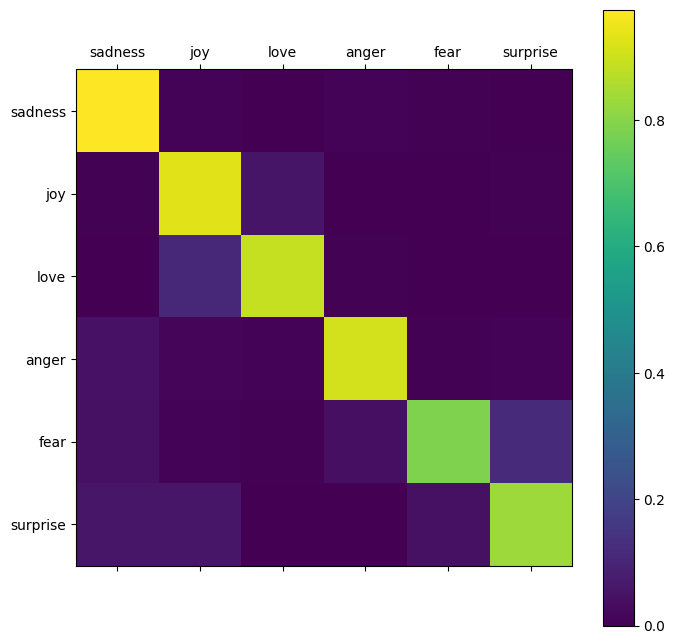

In [21]:
print('Evaluating model on test set...')

# Make predictions on the test set
predictions = model.predict(test_tweets_sequences)

# Convert predictions from probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Select a few random examples from the test set for individual prediction display
num_examples_to_show = 5
random_indices = random.sample(range(len(test_tweets_sequences)), num_examples_to_show)

print(f"\nIndividual predictions for {num_examples_to_show} random test examples:")
for i, idx in enumerate(random_indices):
    true_label_idx = test_labels[idx]
    predicted_label_idx = y_pred[idx]
    predicted_probability = predictions[idx][predicted_label_idx]

    print(f"\nExample {i+1}:")
    print(f"  Tweet: {get_tweets(test_ds)[idx]}")
    print(f"  True Label: {index_to_class[true_label_idx]} ({true_label_idx})")
    print(f"  Predicted Label: {index_to_class[predicted_label_idx]} ({predicted_label_idx})")
    print(f"  Predicted Probability: {predicted_probability:.2f}")

# Display overall evaluation metrics and confusion matrix
print('\nOverall evaluation on test set:')
loss, accuracy = model.evaluate(test_tweets_sequences, test_labels)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Show confusion matrix
show_confusion_matrix(test_labels, y_pred, class_names)